## Title: Data Visualization Notebook

### Author: Nilay Kumar
Multicellular Systems Engineering Lab

### Update Author: Stephen Cini
Dowling Lab

Department of Chemical and Biomolecular Engineering

University of Notre Dame
### Summary
This notebook is used for visualizing the data generated by `master_bayesian_optimization.py`. The data plotted here corresponds to Figure 3 of the manuscript. (Exploration Parameter = 0.05)

In [1]:
# Adding dependencies folder to the path. Dependencies stores all teh classes used in bayesian optimization BO
import sys
sys.path.append("/Users/scini/Documents/GitHub/ReverseEngineeringMorphogenesis/multiobjective_update_StephenCini2026")
# Loading in libraries
import pandas as pd
import matplotlib.pyplot as plt
import spatial_efd
import math 
import signac
import numpy as np
import os.path
import os
import torch
import gpytorch
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
from sklearn.preprocessing import StandardScaler
import similaritymeasures
from scipy.interpolate import interp1d
#from smt.sampling_methods import LHS
# Importing helper libraries for bayesian optimization
from dependencies.data_preprocessing_class import DataPreprocessing
from dependencies.gaussian_process_regression_class import GaussianProcessRegression
from dependencies.acquisition_functions_class import AcqisitionFunctions
from dependencies.geometry_writer import GeometryWriter
from dependencies.feature_extractor_4 import FeatureExtractor

#### 1.  Plotting error between the target shape and shapes resulting from sampled parameters during bayesian optimization

The best error within training data is:0.05925741259220668
The best shape was sampled for iteration:99


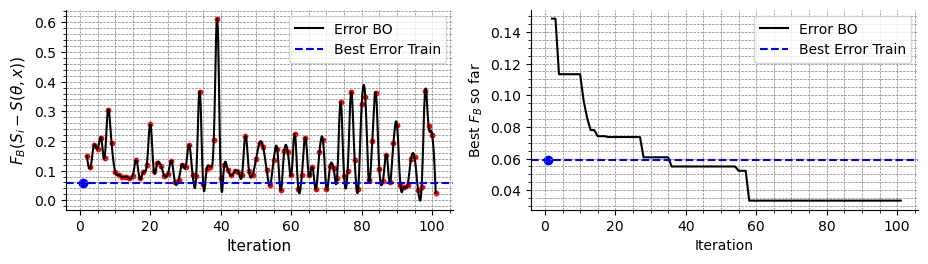

In [4]:
# specifying the total number of iterations in BO
num_iterations_BO = 100
# Loading in the output training data containinh negative of Frechet error for the sampled parametsr
train_y = np.load('output_data/train_y.npy', )
# Isolating the initial training data (pre BO)
data_y = train_y[:149,:]
# Multiplying it by -1 to get the actuall frechet errorss
error_train = data_y*(-1)
# Finding the best sample in training data
error_train_best = np.min(error_train)

# Loading the array storing error beiween the target and sampled shapes
error_target_sampled = np.load('output_data/error_target_sampled.npy',)
error_target_sampled_0 = error_target_sampled

# Finding the best sampled shape with least error
best_shape_so_far = np.argmin(error_target_sampled)
print("The best error within training data is:" + str(error_train_best))
print("The best shape was sampled for iteration:" + str(best_shape_so_far))

# Computing the best error so far
# The value of the quantity at ith iteration is equal to the leat error sampled till ith iteration
error_ds = np.zeros(100,)
error_ds[0] = error_target_sampled[0]
# Itearting over errod calculated over all the iteration in BO
for i in range(num_iterations_BO):
    if i != 0:
        # Estimating the least error so far
        error_ds[i] = (np.amin(error_target_sampled[:i]))
        
"""
Plotting
"""
# Specifiying the index for plottingthe best error observed within the training data
index_train = 1
# Generating the indices for plotting erros for parametrs sampled during the BO process 
index_sampled = np.linspace(2,num_iterations_BO+1,num_iterations_BO)
# Generating a spline fit for the erros
x_new = np.linspace(index_sampled.min(), index_sampled.max(),1000)
f = interp1d(index_sampled, error_target_sampled, kind='quadratic')
y_smooth=f(x_new)

# Plotting the best error in training data and the errors for parametsr sampled during the BO
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(11, 2.6))
plt.rcParams.update({'font.size': 10})
ax[0].scatter(index_train, error_train_best, color="blue")
ax[0].scatter(index_sampled, error_target_sampled, s=10, color="red")
ax[0].plot (x_new,y_smooth, color="black", label = "Error BO")
ax[0].axhline(y=error_train_best, color='b', linestyle='dashed', label = "Best Error Train")
ax[0].set_ylabel(r'$F_{B}(S_{i}-S(\theta ,x))$',  fontsize = 11)
ax[0].set_xlabel("Iteration",  fontsize = 11)
ax[0].grid(which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
ax[0].minorticks_on()
ax[0].grid(which='minor', axis='both', linestyle='--', linewidth=0.5, color='gray')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].legend()

ax[1].scatter(index_train, error_train_best, color="blue")
ax[1].plot (index_sampled, error_ds, color="black",  label = "Error BO")
ax[1].axhline(y=error_train_best, color='b', linestyle='dashed', label = "Best Error Train")
ax[1].set_ylabel("Best $F_{B}$ so far")
ax[1].set_xlabel("Iteration")
ax[1].grid(which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
ax[1].minorticks_on()
ax[1].grid(which='minor', axis='both', linestyle='--', linewidth=0.5, color='gray')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].legend()
plt.show()

__Figure 1: Plot visualizing variation of Frechet distance.__ *Notes: __(A)__ Plot showing the variation of error quantified by Frechet distance between the target and shape generated by SE using sampled parameters from BO. The blue line indicated the frchte distance for the closest shape matching to target shape within the initial GPR  training data.   __(B)__ Plot of best error so bar.*

#### 2. Plotting sampled parameters for the best sampled points using parallel coordinates plot

In [5]:
# Loading in the parametsrs sampled during the BO process
param_sampled = np.load('output_data/param_sampled.npy')
# Defining the threshold error for identofying the best shapes sampled in tertaions
# Setting it equal to the best error observed within the training data
thresh_best_error = error_train_best

# Initializing teh arrays to store the best erros and parametsrs sampled
best_errors = []
best_params = []

# Iterating through all the BO iterations
for i in range(num_iterations_BO):
    # Checking if the error observed within teh step is less than teh threshold error
    if error_target_sampled[i] < thresh_best_error:
        # Adding teh error and teh parameters
        best_params.append(param_sampled[i,:])
        best_errors.append(error_target_sampled[i])

# Transforming the paarmeters to log scale for visualization
best_params_log = np.log(best_params)
# Creating a dataframe using the data thet contains teh parametsr sampled as teh first 6 columsn and the erro sampled as the last column
df = pd.DataFrame(data=best_params_log, columns=["param1", "param2","param3","param4","param5","param6","param7"])
df['errors'] = best_errors

# Using plotly to viusalize the parametsr sampled as parallel coordinate plot
import plotly.express as px
fig = px.parallel_coordinates(df, color="errors",
                              dimensions=['param1', 'param2', 'param3',
                                          'param4', 'param5', 'param6', 'param7'],
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=0.02)
fig.update_layout(width = 800,height = 300,)
fig.show()

In [ ]:
# Saving the data as an excel sheet
df.to_excel("parametsr_sampled_figure3_ep_0_05.xlsx") 